[INFO] Environment setup complete
  G-axis weights: {'G1': 0.3, 'G2': 0.25, 'G3': 0.25, 'G4': 0.2}
[INFO] G1~G4 scores       : 600 records
[INFO] LLM-as-Judge scores: 600 records
[INFO] DeepEval scores    : 180 records
[OK] governance_score column verified
[INFO] Composite score formula:
  composite_score = governance_score × 0.70 + judge_score_norm × 0.30

[INFO] Overall composite score (all):
           count   mean    std    min    25%    50%    75%    max
condition                                                        
baseline   300.0  0.762  0.091  0.360  0.714  0.778  0.835  0.935
rag        300.0  0.816  0.093  0.345  0.773  0.835  0.878  1.000
[Table 8] Composite Governance Score Summary
Condition          Regulation   N  G1 Accuracy  G2 Safety  G3 Transparency  G4 Compliance  Governance Score  Judge Score  Composite Score
 Baseline         NIST AI RMF 100        0.672      0.932            0.744          0.718             0.764        0.755            0.761
      Rag        

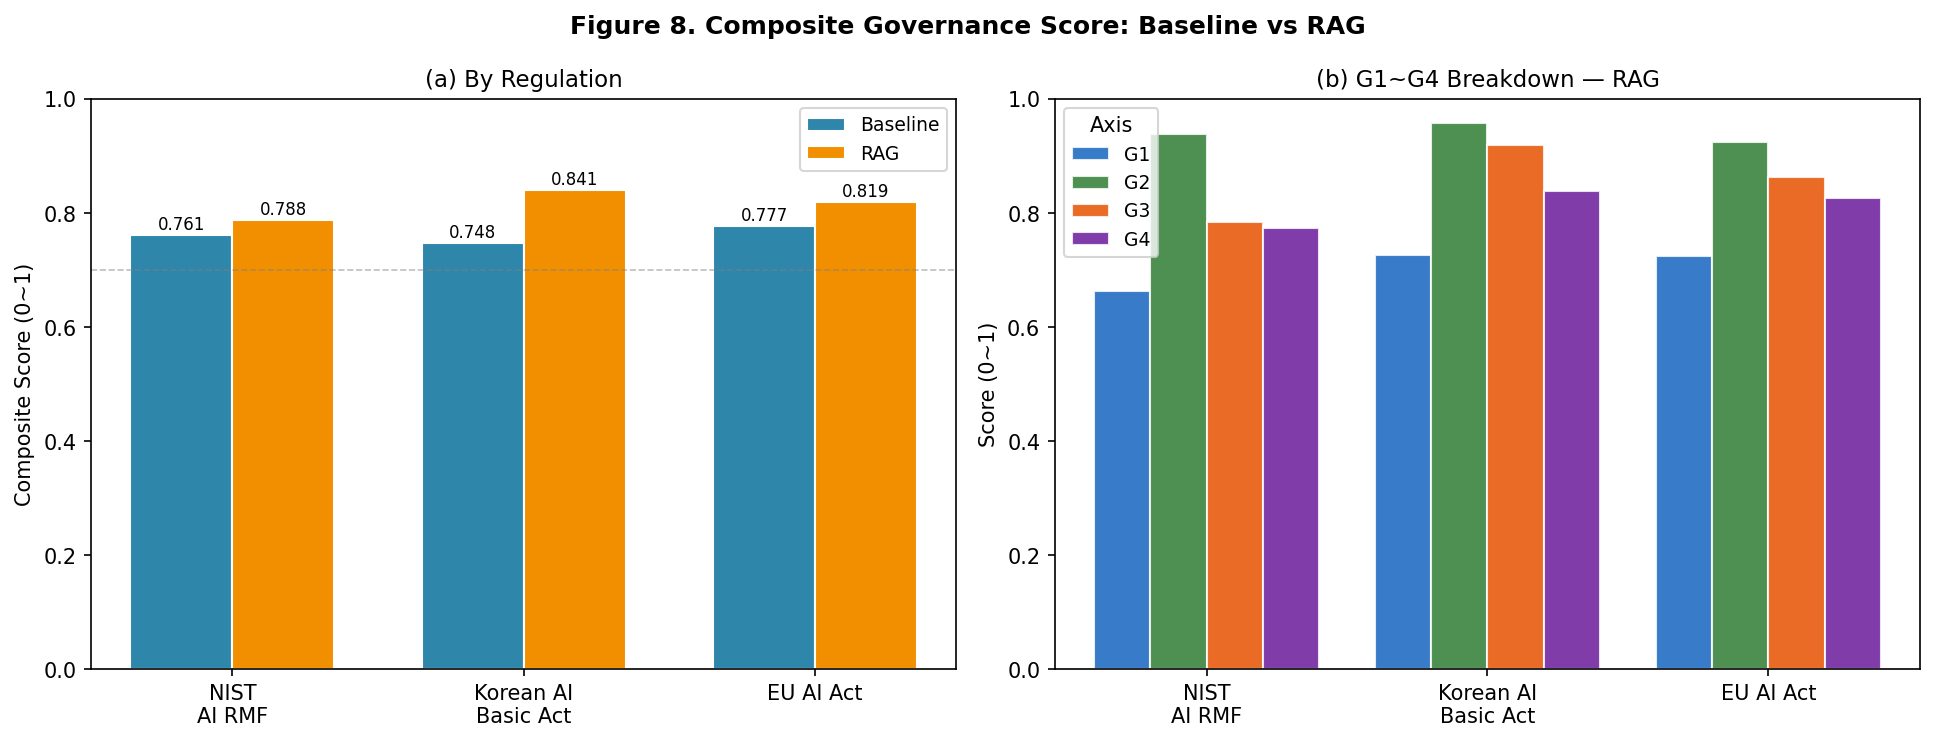

[SAVE] ../results/figures\fig08_governance_score_comparison.png


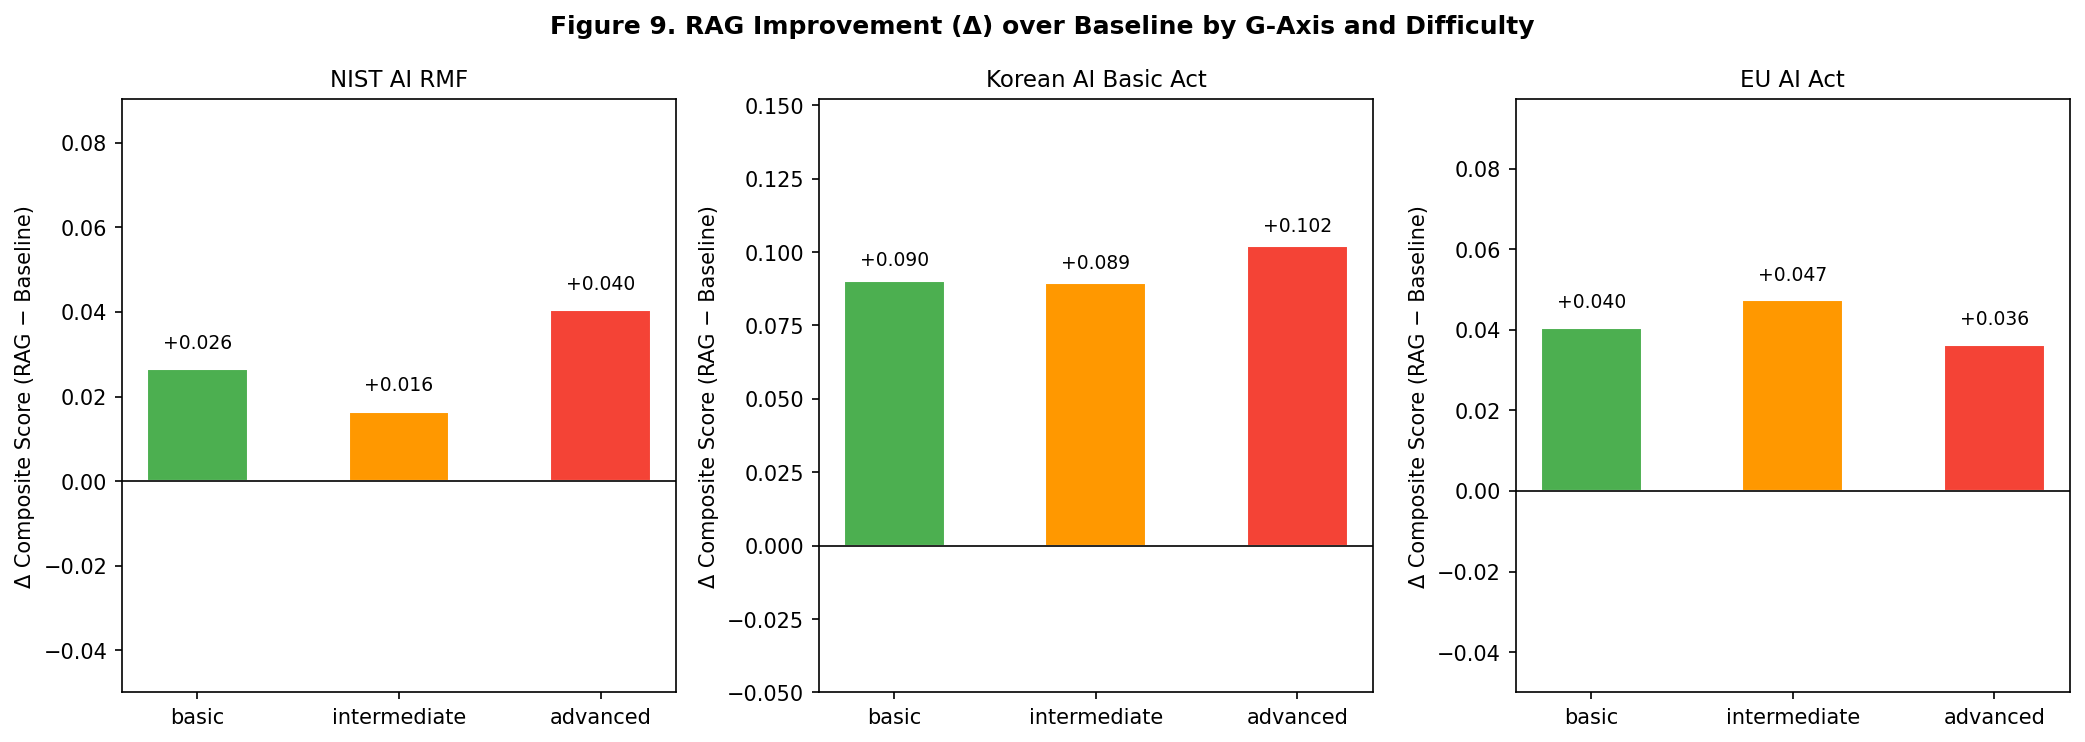

[SAVE] ../results/figures\fig09_baseline_vs_rag.png


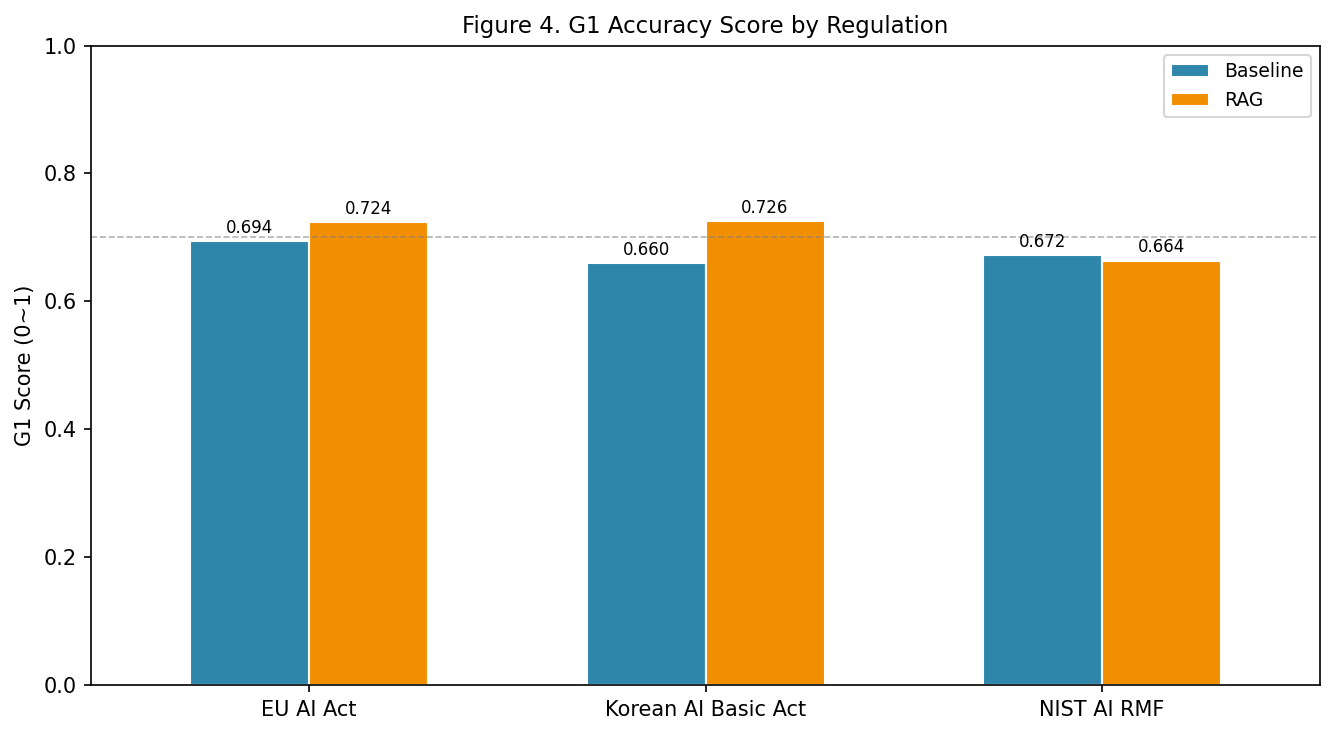

[SAVE] ../results/figures\fig04_g1_accuracy_by_regulation.png


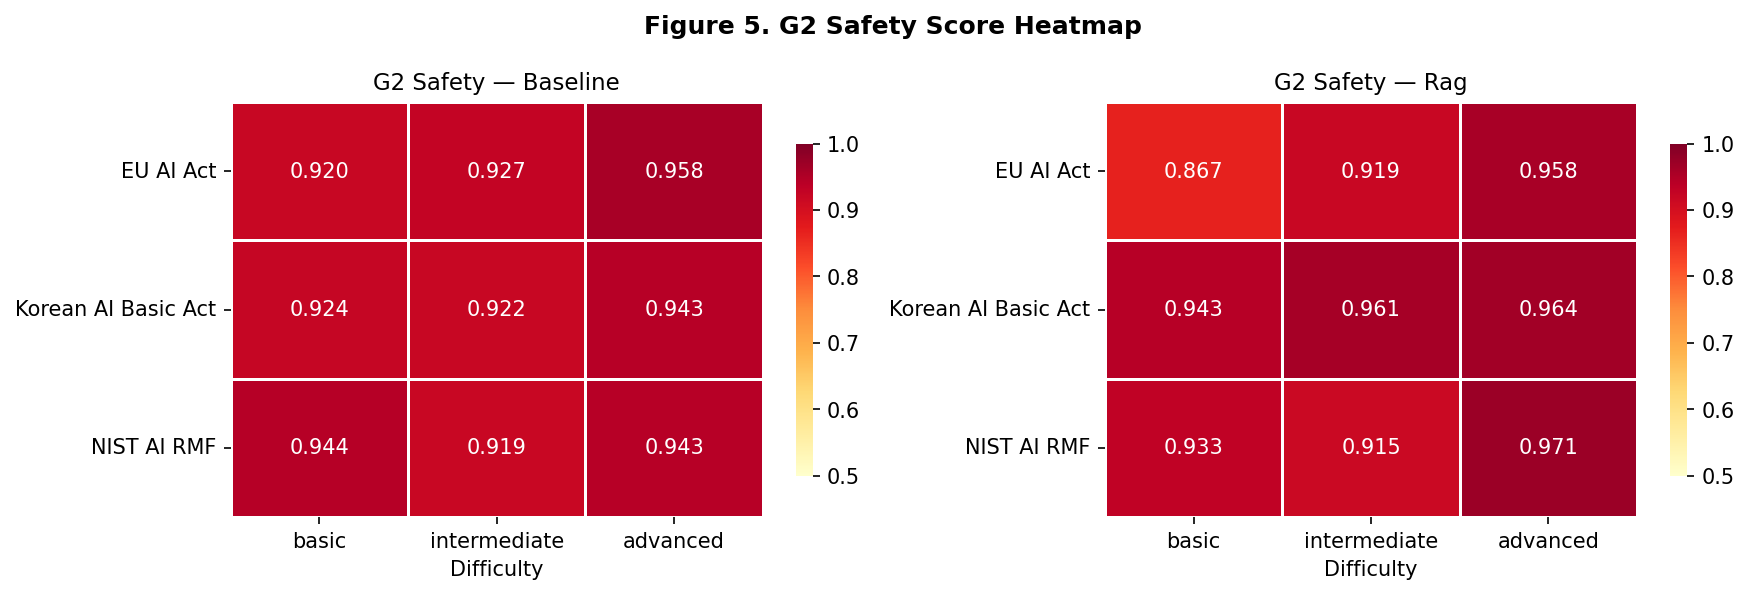

[SAVE] ../results/figures\fig05_g2_safety_heatmap.png


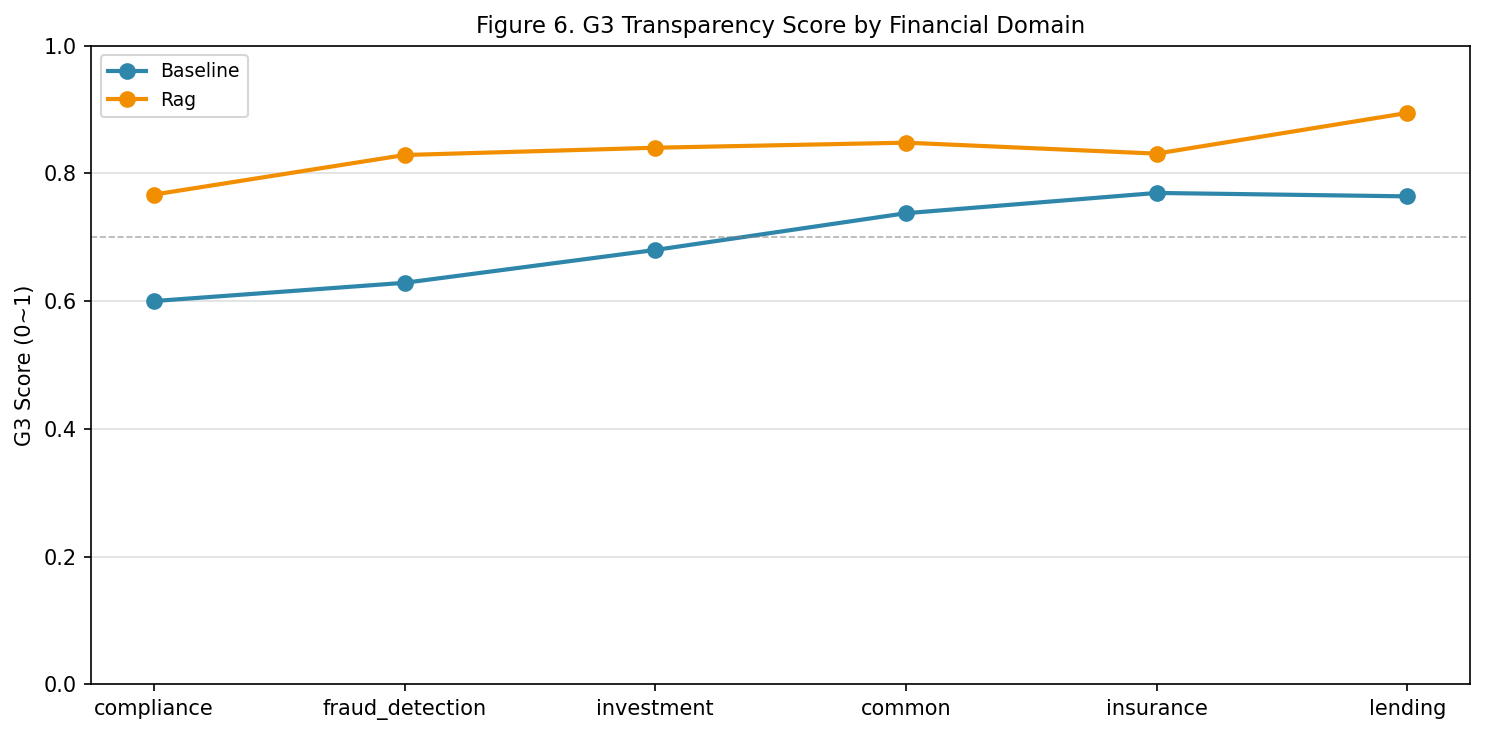

[SAVE] ../results/figures\fig06_g3_transparency_by_domain.png


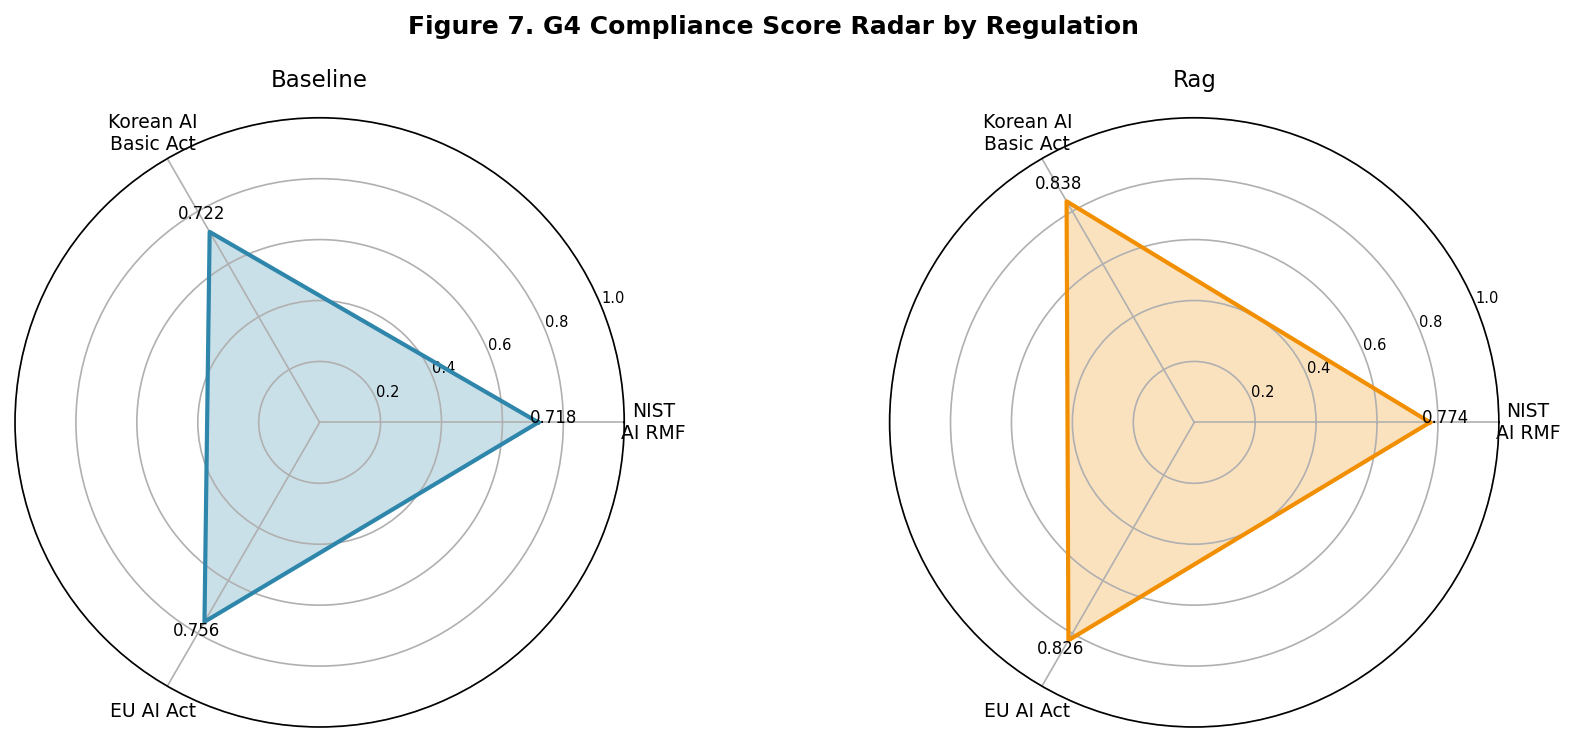

[SAVE] ../results/figures\fig07_g4_compliance_radar.png


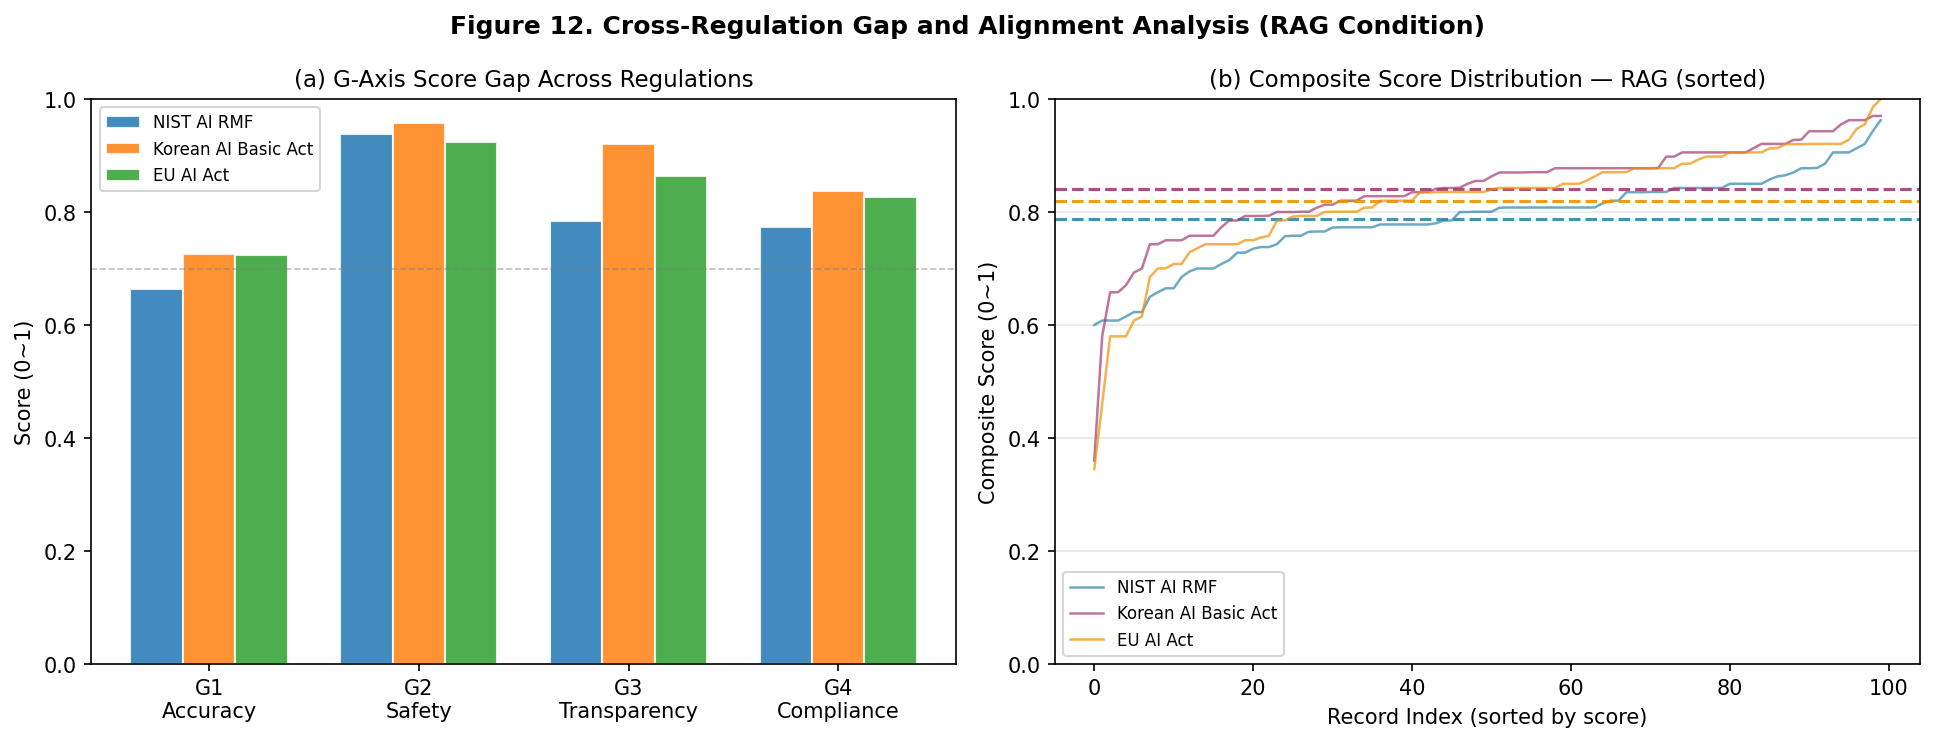

[SAVE] ../results/figures\fig12_regulation_gap_alignment.png
  FINAL RESULTS SUMMARY — ALL NOTEBOOKS

[Composite Governance Score — Overall]
             N  G1_mean  G2_mean  G3_mean  G4_mean  governance_mean  judge_mean  composite_mean
condition                                                                                      
baseline   300    0.675    0.932    0.738    0.732            0.766       0.751           0.762
rag        300    0.705    0.940    0.856    0.813            0.823       0.800           0.816

[RAG Improvement Summary]
  Baseline composite score : 0.7619
  RAG composite score      : 0.8160
  Overall improvement (Δ)  : +0.0541
  Relative improvement     : +7.10%

[Output Files]
  ✅ results/tables/table8_governance_score.csv
  ✅ results/figures/fig04_g1_accuracy_by_regulation.png
  ✅ results/figures/fig05_g2_safety_heatmap.png
  ✅ results/figures/fig06_g3_transparency_by_domain.png
  ✅ results/figures/fig07_g4_compliance_radar.png
  ✅ results/figures/fig08_gove

In [3]:
# %%
# =============================================================================
# 07_governance_score.ipynb
# Financial AI Governance — Composite Governance Score & Final Visualization
# Kernel : Python (llm_env)
# Input  : results/scores/scores_all.csv
#          results/scores/scores_llm_as_judge.csv
#          results/scores/scores_deepeval.csv
# Output : results/tables/table8_governance_score.csv
#          results/figures/fig08_governance_score_comparison.png
#          results/figures/fig09_baseline_vs_rag.png
#          results/figures/fig12_regulation_gap_alignment.png
#          results/figures/fig04_g1_accuracy_by_regulation.png
#          results/figures/fig05_g2_safety_heatmap.png
#          results/figures/fig06_g3_transparency_by_domain.png
#          results/figures/fig07_g4_compliance_radar.png
# =============================================================================

# %%
# =============================================================================
# Cell 1. Libraries and Environment Setup
# =============================================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Directory paths
SCORE_DIR  = '../results/scores'
TABLE_DIR  = '../results/tables'
FIGURE_DIR = '../results/figures'

for d in [TABLE_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# G-axis weights (from research design)
G_WEIGHTS = {'G1': 0.30, 'G2': 0.25, 'G3': 0.25, 'G4': 0.20}

# Regulation label map
REG_MAP = {
    'NIST_AI_RMF'    : 'NIST AI RMF',
    'KR_AI_BASIC_ACT': 'Korean AI Basic Act',
    'EU_AI_ACT'      : 'EU AI Act',
}

# Plot style
plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 10,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'legend.fontsize': 9,
})

COLORS = {'baseline': '#2E86AB', 'rag': '#F18F01'}

print("[INFO] Environment setup complete")
print(f"  G-axis weights: {G_WEIGHTS}")


# %%
# =============================================================================
# Cell 2. Load All Score Files
# =============================================================================
df_g      = pd.read_csv(os.path.join(SCORE_DIR, 'scores_all.csv'))
df_judge  = pd.read_csv(os.path.join(SCORE_DIR, 'scores_llm_as_judge.csv'))
df_de     = pd.read_csv(os.path.join(SCORE_DIR, 'scores_deepeval.csv'))

print(f"[INFO] G1~G4 scores       : {len(df_g)} records")
print(f"[INFO] LLM-as-Judge scores: {len(df_judge)} records")
print(f"[INFO] DeepEval scores    : {len(df_de)} records")

# Verify governance_score column
assert 'governance_score' in df_g.columns, "[ERROR] governance_score missing"
print("[OK] governance_score column verified")


# %%
# =============================================================================
# Cell 3. Composite Governance Score Calculation
# =============================================================================
# Composite = weighted G1~G4 (already in scores_all.csv as governance_score)
# Normalize LLM-as-Judge overall_score from 1~5 scale to 0~1
df_judge['judge_score_norm'] = (df_judge['overall_score'] - 1) / 4

# Merge G scores with Judge scores on id + condition
df_merged = df_g.merge(
    df_judge[['id', 'condition', 'judge_score_norm',
              'regulatory_accuracy', 'practical_utility',
              'completeness', 'clarity', 'risk_awareness']],
    on=['id', 'condition'], how='left'
)

# Final composite score:
# 70% weighted G1~G4 governance score + 30% LLM-as-Judge normalized score
df_merged['composite_score'] = (
    df_merged['governance_score']   * 0.70 +
    df_merged['judge_score_norm']   * 0.30
)

print("[INFO] Composite score formula:")
print("  composite_score = governance_score × 0.70 + judge_score_norm × 0.30")
print(f"\n[INFO] Overall composite score (all):")
print(df_merged.groupby('condition')['composite_score'].describe().round(3).to_string())


# %%
# =============================================================================
# Cell 4. Table 8 — Composite Governance Score Summary (for Paper)
# =============================================================================
rows = []

for reg_key, reg_label in REG_MAP.items():
    for cond in ['baseline', 'rag']:
        sub = df_merged[
            (df_merged['regulation'] == reg_key) &
            (df_merged['condition']  == cond)
        ]
        rows.append({
            'Condition'        : cond.capitalize(),
            'Regulation'       : reg_label,
            'N'                : len(sub),
            'G1 Accuracy'      : round(sub['G1_score'].mean(), 3),
            'G2 Safety'        : round(sub['G2_score'].mean(), 3),
            'G3 Transparency'  : round(sub['G3_score'].mean(), 3),
            'G4 Compliance'    : round(sub['G4_score'].mean(), 3),
            'Governance Score' : round(sub['governance_score'].mean(), 3),
            'Judge Score'      : round(sub['judge_score_norm'].mean(), 3),
            'Composite Score'  : round(sub['composite_score'].mean(), 3),
        })

# Overall rows
for cond in ['baseline', 'rag']:
    sub = df_merged[df_merged['condition'] == cond]
    rows.append({
        'Condition'        : cond.capitalize(),
        'Regulation'       : 'Overall',
        'N'                : len(sub),
        'G1 Accuracy'      : round(sub['G1_score'].mean(), 3),
        'G2 Safety'        : round(sub['G2_score'].mean(), 3),
        'G3 Transparency'  : round(sub['G3_score'].mean(), 3),
        'G4 Compliance'    : round(sub['G4_score'].mean(), 3),
        'Governance Score' : round(sub['governance_score'].mean(), 3),
        'Judge Score'      : round(sub['judge_score_norm'].mean(), 3),
        'Composite Score'  : round(sub['composite_score'].mean(), 3),
    })

table8 = pd.DataFrame(rows)
out_t8 = os.path.join(TABLE_DIR, 'table8_governance_score.csv')
table8.to_csv(out_t8, index=False, encoding='utf-8-sig')

print("[Table 8] Composite Governance Score Summary")
print(table8.to_string(index=False))
print(f"\n[SAVE] {out_t8}")


# %%
# =============================================================================
# Cell 5. Figure 8 — Composite Governance Score Comparison
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Figure 8. Composite Governance Score: Baseline vs RAG',
    fontsize=12, fontweight='bold'
)

reg_labels = list(REG_MAP.values())
reg_keys   = list(REG_MAP.keys())

# (a) Grouped bar — by regulation
ax = axes[0]
x   = np.arange(len(reg_keys))
w   = 0.35
bl_scores  = [df_merged[(df_merged['regulation']==k)&(df_merged['condition']=='baseline')]['composite_score'].mean() for k in reg_keys]
rag_scores = [df_merged[(df_merged['regulation']==k)&(df_merged['condition']=='rag')]['composite_score'].mean() for k in reg_keys]

bars_bl  = ax.bar(x - w/2, bl_scores,  w, label='Baseline', color=COLORS['baseline'], edgecolor='white')
bars_rag = ax.bar(x + w/2, rag_scores, w, label='RAG',      color=COLORS['rag'],      edgecolor='white')
ax.set_title('(a) By Regulation')
ax.set_ylabel('Composite Score (0~1)')
ax.set_xticks(x)
ax.set_xticklabels(['NIST\nAI RMF', 'Korean AI\nBasic Act', 'EU AI Act'])
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='0.7 threshold')
for b, s in zip(bars_bl,  bl_scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{s:.3f}', ha='center', fontsize=8)
for b, s in zip(bars_rag, rag_scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{s:.3f}', ha='center', fontsize=8)

# (b) G1~G4 breakdown — RAG only
ax = axes[1]
g_means = {
    ax_label: [
        df_merged[(df_merged['regulation']==k)&(df_merged['condition']=='rag')][f'{ax_label}_score'].mean()
        for k in reg_keys
    ]
    for ax_label in ['G1', 'G2', 'G3', 'G4']
}
colors_g = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
x2 = np.arange(len(reg_keys))
w2 = 0.2
for i, (g, color) in enumerate(zip(['G1','G2','G3','G4'], colors_g)):
    offset = (i - 1.5) * w2
    bars = axes[1].bar(x2 + offset, g_means[g], w2,
                       label=g, color=color, edgecolor='white', alpha=0.85)
axes[1].set_title('(b) G1~G4 Breakdown — RAG')
axes[1].set_ylabel('Score (0~1)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['NIST\nAI RMF', 'Korean AI\nBasic Act', 'EU AI Act'])
axes[1].set_ylim(0, 1.0)
axes[1].legend(title='Axis')

plt.tight_layout()
out_f8 = os.path.join(FIGURE_DIR, 'fig08_governance_score_comparison.png')
fig.savefig(out_f8, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f8}")


# %%
# =============================================================================
# Cell 6. Figure 9 — Baseline vs RAG Delta by G-Axis
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Figure 9. RAG Improvement (Δ) over Baseline by G-Axis and Difficulty',
    fontsize=12, fontweight='bold'
)

diff_order  = ['basic', 'intermediate', 'advanced']
diff_colors = ['#4CAF50', '#FF9800', '#F44336']

for ax, (reg_key, reg_label) in zip(axes, REG_MAP.items()):
    sub = df_merged[df_merged['regulation'] == reg_key]
    deltas = []
    for diff in diff_order:
        d_sub = sub[sub['difficulty'] == diff]
        bl_mean  = d_sub[d_sub['condition']=='baseline']['composite_score'].mean()
        rag_mean = d_sub[d_sub['condition']=='rag']['composite_score'].mean()
        deltas.append(rag_mean - bl_mean)

    bars = ax.bar(diff_order, deltas, color=diff_colors, edgecolor='white', width=0.5)
    ax.set_title(reg_label)
    ax.set_ylabel('Δ Composite Score (RAG − Baseline)')
    ax.set_ylim(-0.05, max(deltas) + 0.05)
    ax.axhline(0, color='black', linewidth=0.8)
    for b, d in zip(bars, deltas):
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height() + 0.005 if d >= 0 else b.get_height() - 0.015,
                f'{d:+.3f}', ha='center', fontsize=9)

plt.tight_layout()
out_f9 = os.path.join(FIGURE_DIR, 'fig09_baseline_vs_rag.png')
fig.savefig(out_f9, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f9}")


# %%
# =============================================================================
# Cell 7. Figure 4~7 — Per-Axis Detailed Figures
# =============================================================================

# --- Figure 4: G1 Accuracy by Regulation & Condition ---
fig, ax = plt.subplots(figsize=(9, 5))
pivot_g1 = df_merged.groupby(['regulation','condition'])['G1_score'].mean().unstack()
pivot_g1.index = [REG_MAP.get(i,i) for i in pivot_g1.index]
pivot_g1.plot(kind='bar', ax=ax, color=[COLORS['baseline'], COLORS['rag']],
              edgecolor='white', width=0.6)
ax.set_title('Figure 4. G1 Accuracy Score by Regulation')
ax.set_ylabel('G1 Score (0~1)')
ax.set_ylim(0, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Baseline','RAG'])
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
out_f4 = os.path.join(FIGURE_DIR, 'fig04_g1_accuracy_by_regulation.png')
fig.savefig(out_f4, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f4}")

# --- Figure 5: G2 Safety Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cond in zip(axes, ['baseline', 'rag']):
    sub   = df_merged[df_merged['condition'] == cond]
    pivot = sub.groupby(['regulation','difficulty'])['G2_score'].mean().unstack()
    pivot.index = [REG_MAP.get(i,i) for i in pivot.index]
    pivot = pivot[['basic','intermediate','advanced']]
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0.5, vmax=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'shrink':0.8})
    ax.set_title(f'G2 Safety — {cond.capitalize()}')
    ax.set_xlabel('Difficulty')
    ax.set_ylabel('')
fig.suptitle('Figure 5. G2 Safety Score Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
out_f5 = os.path.join(FIGURE_DIR, 'fig05_g2_safety_heatmap.png')
fig.savefig(out_f5, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f5}")

# --- Figure 6: G3 Transparency by Financial Domain ---
fig, ax = plt.subplots(figsize=(10, 5))
dom_order = df_merged.groupby('financial_domain')['G3_score'].mean().sort_values().index.tolist()
for cond, color in COLORS.items():
    means = [
        df_merged[(df_merged['financial_domain']==d)&(df_merged['condition']==cond)]['G3_score'].mean()
        for d in dom_order
    ]
    ax.plot(dom_order, means, marker='o', color=color,
            label=cond.capitalize(), linewidth=2, markersize=7)
ax.set_title('Figure 6. G3 Transparency Score by Financial Domain')
ax.set_ylabel('G3 Score (0~1)')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
out_f6 = os.path.join(FIGURE_DIR, 'fig06_g3_transparency_by_domain.png')
fig.savefig(out_f6, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f6}")

# --- Figure 7: G4 Compliance Radar Chart ---
from matplotlib.patches import FancyArrowPatch

categories = list(REG_MAP.values())
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         subplot_kw=dict(polar=True))
fig.suptitle('Figure 7. G4 Compliance Score Radar by Regulation',
             fontsize=12, fontweight='bold')

for ax, cond in zip(axes, ['baseline', 'rag']):
    values = [
        df_merged[(df_merged['regulation']==k)&(df_merged['condition']==cond)]['G4_score'].mean()
        for k in REG_MAP.keys()
    ]
    values += values[:1]
    ax.plot(angles, values, color=COLORS[cond], linewidth=2)
    ax.fill(angles, values, color=COLORS[cond], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['NIST\nAI RMF', 'Korean AI\nBasic Act', 'EU AI Act'], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
    ax.set_title(cond.capitalize(), pad=15)
    for angle, val, label in zip(angles[:-1], values[:-1], categories):
        ax.text(angle, val + 0.05, f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
out_f7 = os.path.join(FIGURE_DIR, 'fig07_g4_compliance_radar.png')
fig.savefig(out_f7, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f7}")


# %%
# =============================================================================
# Cell 8. Figure 12 — Regulation Gap & Alignment Analysis
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Figure 12. Cross-Regulation Gap and Alignment Analysis (RAG Condition)',
    fontsize=12, fontweight='bold'
)

rag_only = df_merged[df_merged['condition'] == 'rag']

# (a) G-axis score gap across regulations
ax = axes[0]
g_axes   = ['G1', 'G2', 'G3', 'G4']
g_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
x = np.arange(len(g_axes))
w = 0.25

for i, (reg_key, reg_label) in enumerate(REG_MAP.items()):
    sub    = rag_only[rag_only['regulation'] == reg_key]
    scores = [sub[f'{g}_score'].mean() for g in g_axes]
    offset = (i - 1) * w
    ax.bar(x + offset, scores, w, label=reg_label, edgecolor='white', alpha=0.85)

ax.set_title('(a) G-Axis Score Gap Across Regulations')
ax.set_ylabel('Score (0~1)')
ax.set_xticks(x)
ax.set_xticklabels(['G1\nAccuracy', 'G2\nSafety', 'G3\nTransparency', 'G4\nCompliance'])
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# (b) Composite score distribution by regulation — RAG vs Baseline
ax = axes[1]
for reg_key, reg_label, color in zip(
    REG_MAP.keys(),
    REG_MAP.values(),
    ['#2E86AB', '#A23B72', '#F18F01']
):
    sub_rag = df_merged[
        (df_merged['regulation'] == reg_key) &
        (df_merged['condition']  == 'rag')
    ]['composite_score']
    ax.plot(range(len(sub_rag)), sorted(sub_rag.values),
            alpha=0.7, linewidth=1.2, color=color, label=reg_label)
    ax.axhline(sub_rag.mean(), color=color, linestyle='--',
               linewidth=1.5, alpha=0.9)

ax.set_title('(b) Composite Score Distribution — RAG (sorted)')
ax.set_xlabel('Record Index (sorted by score)')
ax.set_ylabel('Composite Score (0~1)')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_f12 = os.path.join(FIGURE_DIR, 'fig12_regulation_gap_alignment.png')
fig.savefig(out_f12, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_f12}")


# %%
# =============================================================================
# Cell 9. Final Summary — All Results
# =============================================================================
print("=" * 65)
print("  FINAL RESULTS SUMMARY — ALL NOTEBOOKS")
print("=" * 65)

print("\n[Composite Governance Score — Overall]")
summary = df_merged.groupby('condition').agg(
    N               = ('composite_score', 'count'),
    G1_mean         = ('G1_score',        'mean'),
    G2_mean         = ('G2_score',        'mean'),
    G3_mean         = ('G3_score',        'mean'),
    G4_mean         = ('G4_score',        'mean'),
    governance_mean = ('governance_score','mean'),
    judge_mean      = ('judge_score_norm','mean'),
    composite_mean  = ('composite_score', 'mean'),
).round(3)
print(summary.to_string())

print("\n[RAG Improvement Summary]")
bl_comp  = df_merged[df_merged['condition']=='baseline']['composite_score'].mean()
rag_comp = df_merged[df_merged['condition']=='rag']['composite_score'].mean()
print(f"  Baseline composite score : {bl_comp:.4f}")
print(f"  RAG composite score      : {rag_comp:.4f}")
print(f"  Overall improvement (Δ)  : {rag_comp - bl_comp:+.4f}")
print(f"  Relative improvement     : {(rag_comp - bl_comp) / bl_comp * 100:+.2f}%")

print("\n[Output Files]")
outputs = [
    'results/tables/table8_governance_score.csv',
    'results/figures/fig04_g1_accuracy_by_regulation.png',
    'results/figures/fig05_g2_safety_heatmap.png',
    'results/figures/fig06_g3_transparency_by_domain.png',
    'results/figures/fig07_g4_compliance_radar.png',
    'results/figures/fig08_governance_score_comparison.png',
    'results/figures/fig09_baseline_vs_rag.png',
    'results/figures/fig12_regulation_gap_alignment.png',
]
for f in outputs:
    status = '✅' if os.path.exists(f'../{f}') else '❌'
    print(f"  {status} {f}")

print(f"\n✅ Notebook 07 complete — All experiments finished.")
print(f"   Next: Paper writing (Section 4 & 5)")